In [1]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import constants as cst
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [2]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [3]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [4]:
cmap_cool = cm.cool
cmap_dark_blue_to_cyan = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(0.0)])
cmap_viridis = cm.viridis      # excellent general-purpose
cmap_cividis = cm.cividis      # best for accessibility (colorblind-safe)
cmap_turbo   = cm.turbo        # very high contrast, vivid range
cmap_plasma  = cm.plasma       # strong contrast, warm highlights
cmap_inferno = cm.inferno      # dark-to-bright, great on dark BG
cmap_magma   = cm.magma        # smoother dark-background readability

  Pixels: width = 666.4 x height = 671.2
  Aspect ratio: 0.9928
  Pixels: width = 666.4 x height = 671.2
  Aspect ratio: 0.9928


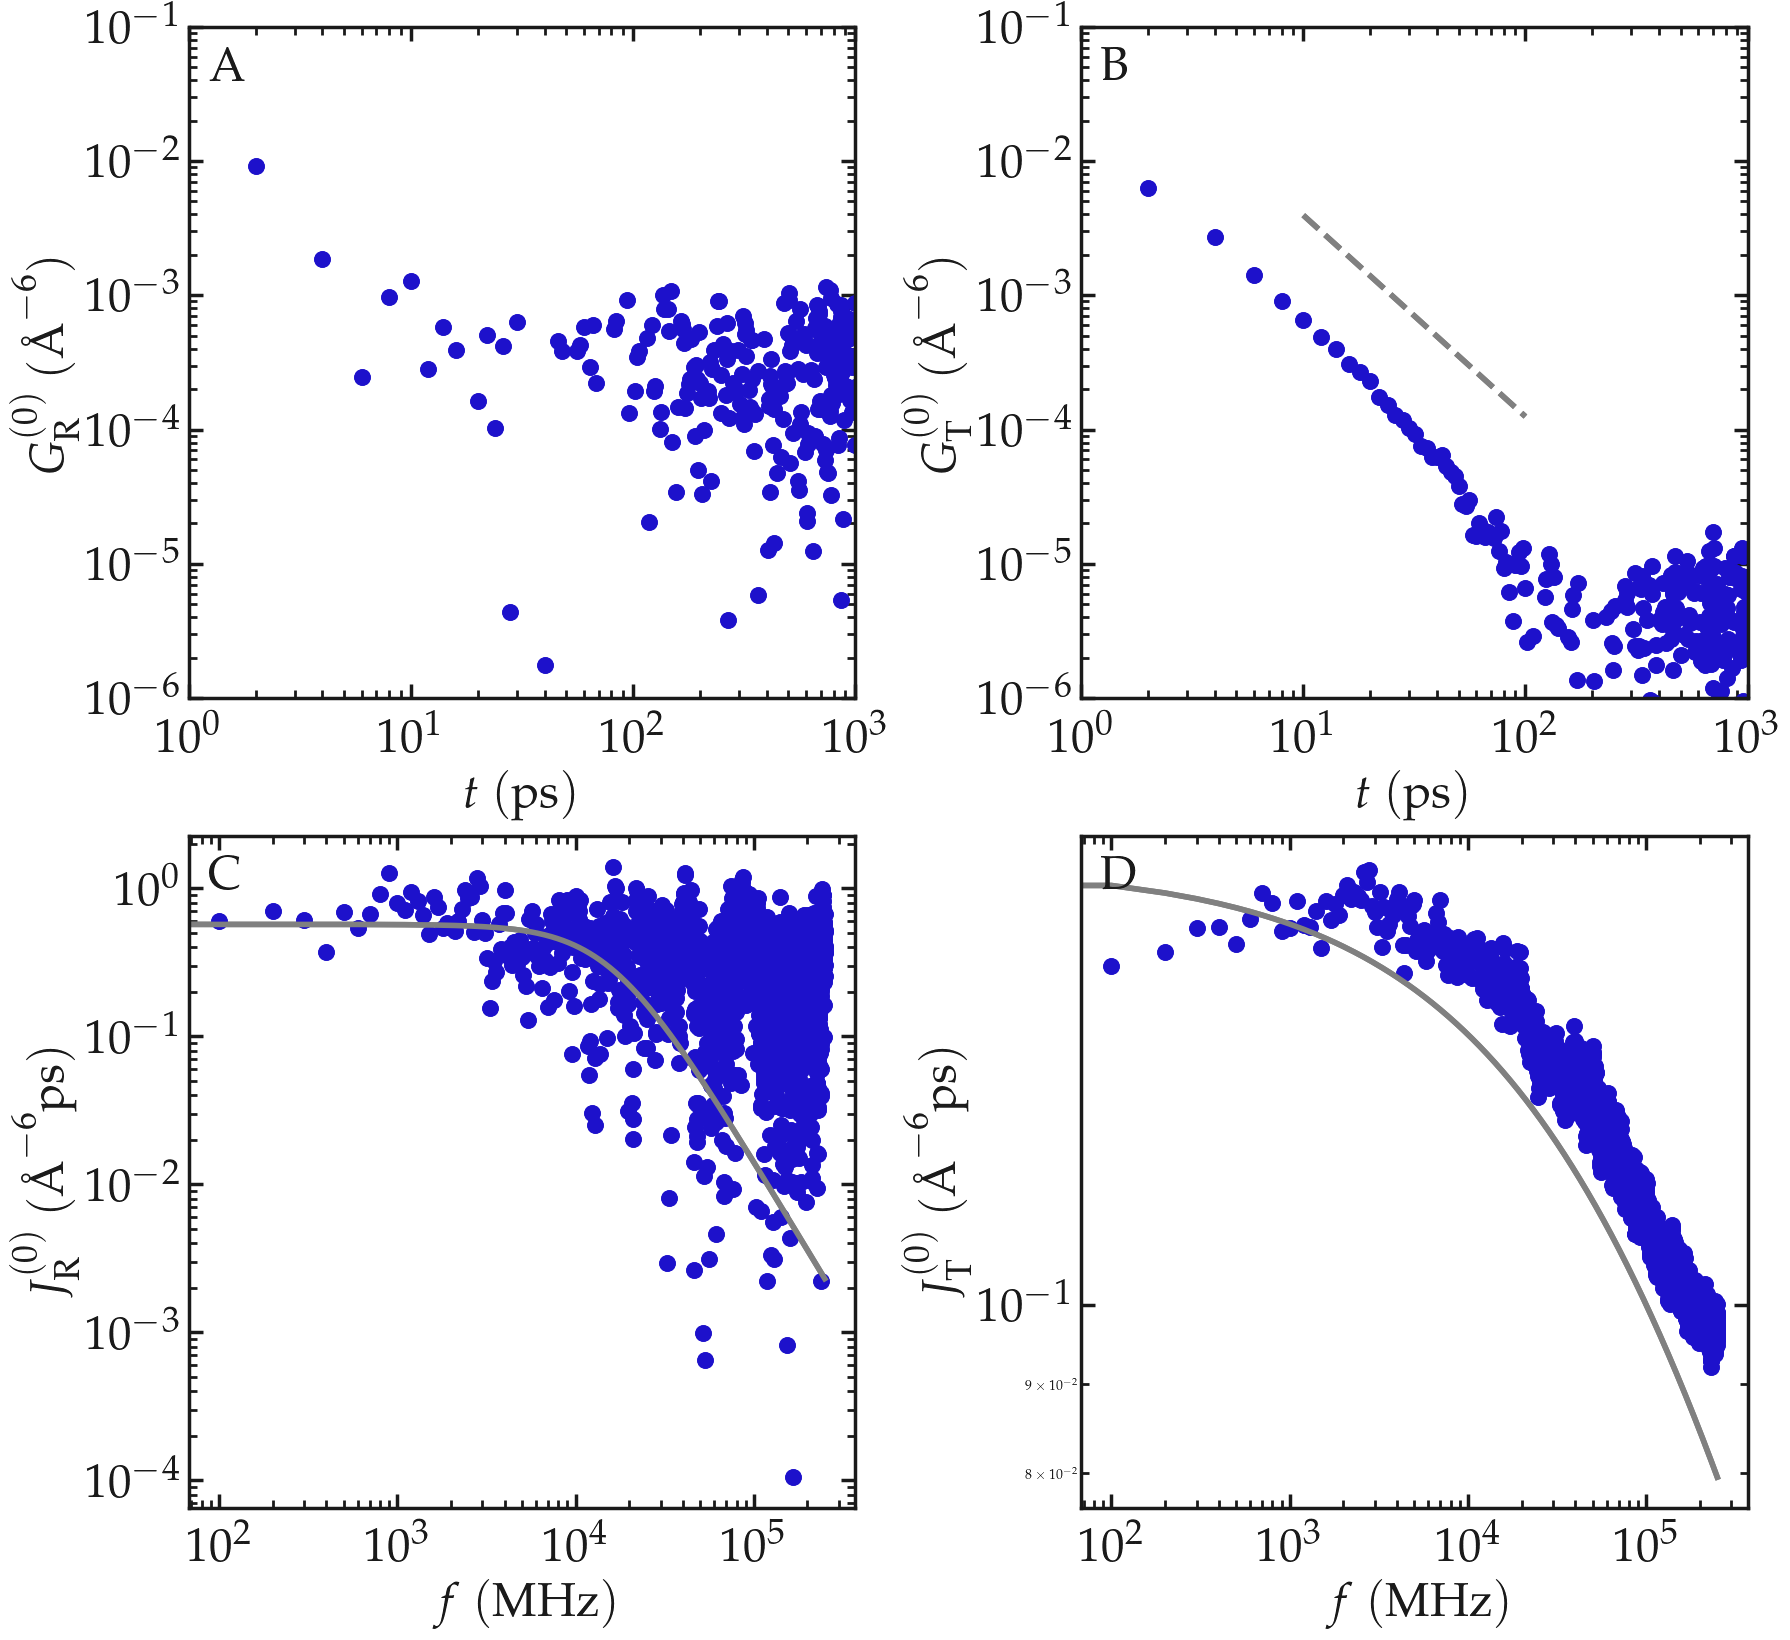

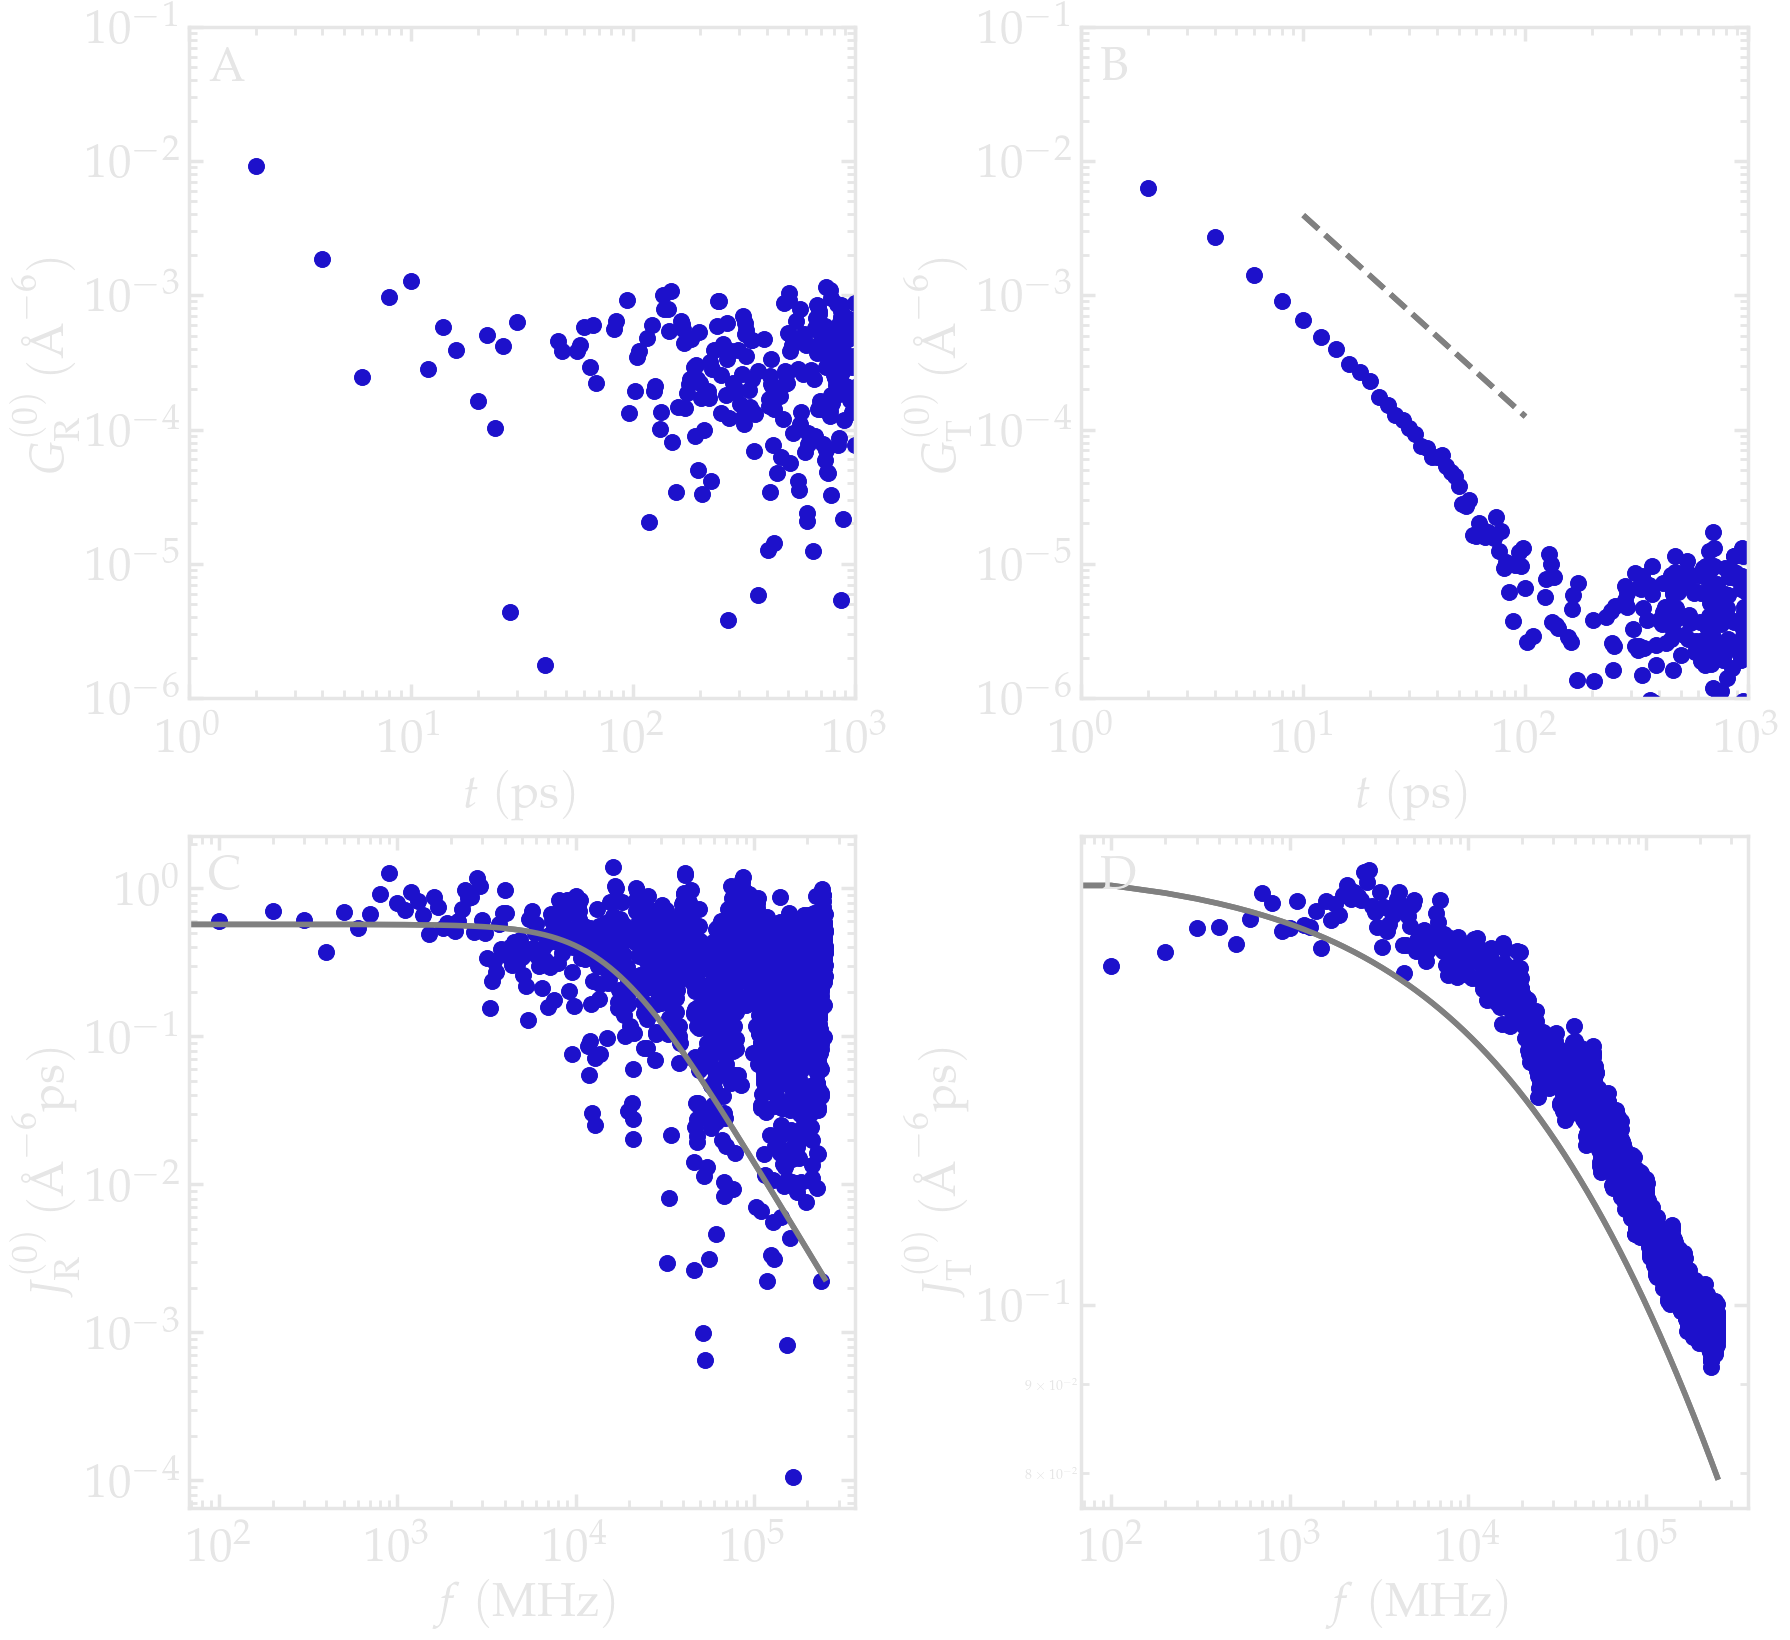

In [52]:
data_path = git_path + "/.submodules/dataset-pure-water/analysis/"

n = 5
filename = "spectra"
colors = cmap_dark_blue_to_cyan(np.linspace(0, 1, 3))

for dark_mode in [False, True]:

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (18,16.5), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2, n_line = 2)


    # Panel 1
    type = "intra"
    myplt.add_panel()
    repetition = 0
    result_file =data_path +  f"nmr_{type}/result{n}-{repetition}.npy"
    data = np.load(result_file, allow_pickle=True).item()
    t = data["t"]
    gij_0 = data["C"][0]

    myplt.add_plot(x = t, y = gij_0, type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3], markersize = 12,
                data_label = r'$G^{(0)}$')
    
    myplt.complete_panel(ylabel = r'$G_\mathrm{R}^{(0)} ~(\mathrm{\AA{}}^{-6})$', xlabel = r'$t~(\mathrm{ps})$',
                         xpad = 15, legend=False, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(1, 1000), y_boundaries=(1e-6, 0.1))


    # Panel 2
    type = "inter"
    myplt.add_panel()
    repetition = 0
    result_file =data_path +  f"nmr_{type}/result{n}-{repetition}.npy"
    data = np.load(result_file, allow_pickle=True).item()
    t = data["t"]
    gij_0 = data["C"][0]

    myplt.add_plot(x = t, y = gij_0, type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3], markersize = 12,
                data_label = r'$G^{(0)}$')
    
    x = np.linspace(10, 100)
    myplt.add_plot(x = x, y = x**(-1.5)/8, type = "loglog", linewidth_data = 3,
                marker = "--", data_color = np.array([0.5, 0.5, 0.5]), markersize = 12,
                data_label = r'$G^{(0)}$')
    
    myplt.complete_panel(ylabel = r'$G_\mathrm{T}^{(0)} ~(\mathrm{\AA{}}^{-6})$', xlabel = r'$t~(\mathrm{ps})$',
                         xpad = 15, legend=False, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(1, 1000), y_boundaries=(1e-6, 0.1))

    # Panel 3
    type = "intra"
    myplt.add_panel()
    repetition = 0
    result_file =data_path +  f"nmr_{type}/result{n}-{repetition}.npy"
    data = np.load(result_file, allow_pickle=True).item()
    f = data["f"] # MHz
    J = data["J"] # A-6 s

    myplt.add_plot(x = f, y = J[0]*1e12, type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3], markersize = 12,
                data_label = r'$J^{(0)}$')

    def J_debye(f_MHz, tau_ps, G0):
        """
        Debye spectral density.

        Parameters
        ----------
        f_MHz : frequency in MHz
        tau_ps : correlation time in ps
        G0 : G(0) in Å⁻⁶

        Returns
        -------
        J : Å⁻⁶ s
        """
        omega = 2 * np.pi * f_MHz * 1e6      # rad/s
        tau = tau_ps * 1e-12                 # s

        return 2 * G0 * tau / (1 + (omega * tau)**2)

    tau = 10 # ps
    G0 = gij_0[0] # A-6
    J_fit = J_debye(f, tau, G0) # should be A-6 ps
    myplt.add_plot(x = f, y = J_fit * 1e12, type = "loglog", linewidth_data = 3,
                marker = "-", data_color = np.array([0.5, 0.5, 0.5]), markersize = 12)

    myplt.complete_panel(ylabel = r'$J_\mathrm{R}^{(0)} ~(\mathrm{\AA{}}^{-6} \mathrm{ps})$', xlabel = r'$f~(\mathrm{MHz})$',
                         xpad = 15, legend=False, handlelength_legend=1)


    # myplt.set_boundaries(x_boundaries=(1, 1000), y_boundaries=(1e-6, 0.1))


    # Panel 4
    type = "inter"
    myplt.add_panel()
    repetition = 0
    result_file =data_path +  f"nmr_{type}/result{n}-{repetition}.npy"
    data = np.load(result_file, allow_pickle=True).item()
    f = data["f"]
    J = data["J"]

    def J_diffusion(f_MHz, J0, A, B):
        """
        Intermolecular spectral density (ADHF model).

        Model
        -----
            J(f) = J0 / (1 + A + B * sqrt(2π f))

        where the input frequency is given in MHz and converted internally
        to Hz.

        Parameters
        ----------
        f_MHz : array_like
            Frequency in MHz.
        J0 : float
            Zero-frequency spectral density, J(0), in Å⁻⁶ s.
        A : float
            Dimensionless offset accounting for finite residence-time effects.

            In the ADHF model,

                A = k r / D,

            where
                k : effective exchange rate (m s⁻¹),
                r : molecular radius (m),
                D : self-diffusion coefficient (m² s⁻¹).

            For ambient liquid water, A is typically of order unity or
            smaller (≈ 0.0-0.5).
        B : float
            Diffusion parameter (s¹ᐟ²).

            In the ADHF model,

                B = r / sqrt(D),

            where r is the molecular radius and D the self-diffusion
            coefficient.

            For water at 300 K,

                D ≈ 2.3 x 10⁻⁹ m² s⁻¹
                r ≈ 1.5 Å

            giving

                B ≈ 3 x 10⁻⁶ s¹ᐟ².

            Typical values lie between 2 x 10⁻⁶ and 4 x 10⁻⁶ s¹ᐟ².

        Returns
        -------
        ndarray
            Spectral density in Å⁻⁶ s.
        """
        f = np.asarray(f_MHz) * 1e6  # Hz
        return J0 / (1.0 + A + B * np.sqrt(2 * np.pi * f))

    J0 = 0.18      # Å^-6 s
    A  = 0.008       # dimensionless
    B  = 1e-6      # s^1/2

    J_fit = J_diffusion(f, J0=J0, A=A, B=B)

    myplt.add_plot(x = f, y = J[0]*1e12, type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3], markersize = 12,
                data_label = r'$J^{(0)}$')
        
    myplt.add_plot(x=f, y = J_fit, type="loglog", marker="-",
        linewidth_data=3, data_color=np.array([0.5,0.5,0.5]))

    myplt.complete_panel(ylabel = r'$J_\mathrm{T}^{(0)} ~(\mathrm{\AA{}}^{-6} \mathrm{ps})$', xlabel = r'$f~(\mathrm{MHz})$',
                         xpad = 15, legend=False, handlelength_legend=1)
    # myplt.set_boundaries(x_boundaries=(1, 1000), y_boundaries=(1e-6, 0.1))

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = filename, saving_path = git_path+path_figures)